**Seeding for reproducibility**

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [2]:
# role of SEED==Same dataset split, Same weight initialization..Each run same results
# we use random state as same concept but inside sklearn

**Importing the dependencies**

In [14]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

Upload the kaggle.json file

In [4]:
!pip install kaggle

  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
Using cached kaggle-2.0.0-py3-none-any.whl (75 kB)
Using cached kagglesdk-0.1.16-py3-none-any.whl (160 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import os

path_to_key = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\uneeded_plant\kaggle.json"

with open(path_to_key) as f:
    kaggle_credentials = json.load(f)

print("✅ Success! Logged in as:", kaggle_credentials['username'])

✅ Success! Logged in as: harshitpurohit44


In [3]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentials["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentials["key"]

In [8]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

^C


In [8]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
data_dir = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\uneeded_plant\dataset\plantvillage dataset"

# List the subfolders (the plant disease classes)
if os.path.exists(data_dir):
    classes = os.listdir(data_dir)
    print(f"Successfully found {len(classes)} classes!")
    print("Top 5 classes:", classes[:5])
else:
    print("Error: The path is incorrect. Please double-check the folder location.")

Successfully found 3 classes!
Top 5 classes: ['color', 'grayscale', 'segmented']


In [5]:
base_path = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\uneeded_plant\dataset\plantvillage dataset"

# 1. Check the main folder
print("Main Folders:", os.listdir(base_path))

# 2. Check Segmented
segmented_path = os.path.join(base_path, "segmented")
print(f"\nSegmented count: {len(os.listdir(segmented_path))}")
print("Samples:", os.listdir(segmented_path)[:5])

# 3. Check Color
color_path = os.path.join(base_path, "color")
print(f"\nColor count: {len(os.listdir(color_path))}")
print("Samples:", os.listdir(color_path)[:5])

# 4. Check Grayscale
grayscale_path = os.path.join(base_path, "grayscale")
print(f"\nGrayscale count: {len(os.listdir(grayscale_path))}")
print("Samples:", os.listdir(grayscale_path)[:5])

Main Folders: ['color', 'grayscale', 'segmented']

Segmented count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Color count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Grayscale count: 38
Samples: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [11]:
'''with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()'''

'with ZipFile("plantvillage-dataset.zip", \'r\') as zip_ref:\n    zip_ref.extractall()'

In [12]:
'''print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])'''

'print(os.listdir("plantvillage dataset"))\n\n\nprint(len(os.listdir("plantvillage dataset/segmented")))\nprint(os.listdir("plantvillage dataset/segmented")[:5])\n\nprint(len(os.listdir("plantvillage dataset/color")))\nprint(os.listdir("plantvillage dataset/color")[:5])\n\nprint(len(os.listdir("plantvillage dataset/grayscale")))\nprint(os.listdir("plantvillage dataset/grayscale")[:5])'

**Number of Classes = 38**

In [6]:
BASE_DIR = r"C:\Users\Jagdish singh\OneDrive\Desktop\placement\uneeded_plant\dataset\plantvillage dataset"

# 2. Create sub-paths using os.path.join (Safest way to handle paths)
COLOR_DIR = os.path.join(BASE_DIR, "color")
SEGMENTED_DIR = os.path.join(BASE_DIR, "segmented")
GRAYSCALE_DIR = os.path.join(BASE_DIR, "grayscale")

# 3. Test a specific class safely
grape_healthy_path = os.path.join(COLOR_DIR, "Grape___healthy")

if os.path.exists(grape_healthy_path):
    print(f"Success! Found {len(os.listdir(grape_healthy_path))} images.")
    print("First 5 files:", os.listdir(grape_healthy_path)[:5])
else:
    print("Error: Path not found. Check if 'color' and 'Grape___healthy' exist inside the BASE_DIR.")

Success! Found 423 images.
First 5 files: ['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


In [17]:
'''print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])'''

'print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))\nprint(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])'

In [ ]:
BASE_PATH = os.path.join("..", "uneeded_plant", "dataset", "plantvillage dataset")

COLOR_DIR = os.path.join(BASE_PATH, "color")
grape_folder = os.path.join(COLOR_DIR, "Grape___healthy")

if os.path.exists(grape_folder):
    print(f"✅ Success! Found it in the neighbor folder.")
    print(f"Total images: {len(os.listdir(grape_folder))}")
else:
    print("❌ Still not found!")
    print(f"Current Directory: {os.getcwd()}")
    print(f"Looking here: {os.path.abspath(grape_folder)}")

✅ Success! Found it in the neighbor folder.
Total images: 423


**Data Preprocessing**

In [11]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

Image Shape: (256, 256, 3)


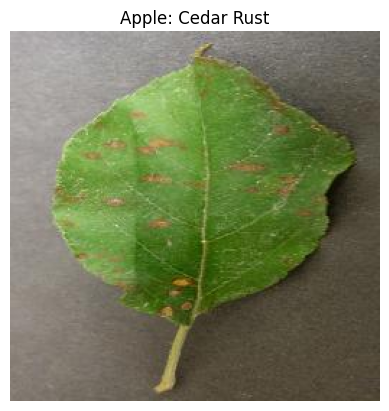

In [16]:
image_path = os.path.join("..", "uneeded_plant", "dataset", "plantvillage dataset", "color", 
                          "Apple___Cedar_apple_rust", "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG")


if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    print(f"Image Shape: {img.shape}")
    
    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title("Apple: Cedar Rust")
    plt.show()
else:
    print("❌ Still can't find that specific image file.")
    print("Double check if the filename has any extra spaces!")

In [18]:
image_path = os.path.join("..", "uneeded_plant", "dataset", "plantvillage dataset", "color", 
                          "Apple___Cedar_apple_rust", "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG")

img = mpimg.imread(image_path)

print(img)

[[[179 175 176]
  [181 177 178]
  [184 180 181]
  ...
  [115 112 105]
  [108 105  98]
  [101  98  91]]

 [[176 172 173]
  [177 173 174]
  [178 174 175]
  ...
  [113 110 103]
  [111 108 101]
  [109 106  99]]

 [[180 176 177]
  [180 176 177]
  [180 176 177]
  ...
  [108 105  98]
  [111 108 101]
  [114 111 104]]

 ...

 [[137 128 119]
  [131 122 113]
  [125 116 107]
  ...
  [ 74  65  48]
  [ 74  65  48]
  [ 73  64  47]]

 [[136 127 118]
  [132 123 114]
  [128 119 110]
  ...
  [ 77  69  50]
  [ 75  67  48]
  [ 75  67  48]]

 [[133 124 115]
  [133 124 115]
  [132 123 114]
  ...
  [ 81  73  54]
  [ 80  72  53]
  [ 79  71  52]]]


In [19]:
img.shape

(256, 256, 3)

In [20]:
height, width, channels = img.shape
img_size = height 
print(f"Original Image Height: {height}")
print(f"Original Image Width: {width}")
print(f"Color Channels: {channels}")

Original Image Height: 256
Original Image Width: 256
Color Channels: 3


In [37]:
# Image Parameters  changed from 224 to 64 to make faster training
img_size = 64
batch_size = 64

**Train Test Split**

In [38]:
# Image Data Generators = rescales + real time augmentation + memory efficient batch loading 
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20%
)

In [39]:
# Train Generator
base_dir = os.path.join("..", "uneeded_plant", "dataset", "plantvillage dataset", "color")
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [40]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


**Convolutional Neural Network**

In [ ]:
'''from tensorflow.keras import layers, models, optimizers

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))

model.add(layers.Dropout(0.5)) 

model.add(layers.Dense(train_generator.num_classes, activation='softmax'))'''

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
'''model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))'''

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
from tensorflow.keras import layers, models, optimizers


model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.GlobalAveragePooling2D(), 
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
# model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,614 (127.40 KB)

 Trainable params: 32,614 (127.40 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
custom_adam = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=custom_adam,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# optimzation added with learning rate 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,614 (127.40 KB)

 Trainable params: 32,614 (127.40 KB)

 Non-trainable params: 0 (0.00 B)

**Model training**

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping (Prevents wasting time if model stops improving)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. Run the Training
# Note: We limit steps_per_epoch to 100 to save HUGE amounts of time
history = model.fit(
    train_generator,
    steps_per_epoch=100,           # Only looks at 100 batches (approx 3200 images) per epoch
    epochs=10,                     # 10 quick rounds
    validation_data=validation_generator,
    validation_steps=20,           # Quick check on 20 batches of validation data
    callbacks=[early_stop],        # Automatically stops if it gets "stuck"
    verbose=1                      # Shows the progress bar
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.1177 - loss: 3.4223 - val_accuracy: 0.1781 - val_loss: 3.2503
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.2033 - loss: 3.0883 - val_accuracy: 0.2133 - val_loss: 2.8960
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.2247 - loss: 2.8795 - val_accuracy: 0.2508 - val_loss: 2.7095
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.2491 - loss: 2.7276 - val_accuracy: 0.2844 - val_loss: 2.5811
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.2597 - loss: 2.6478 - val_accuracy: 0.2883 - val_loss: 2.5538
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.2939 - loss: 2.5516 - val_accuracy: 0.3453 - val_loss: 2.4202
Epoch 7/10
 79/100 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.3170 - loss: 2.4697

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.3180 - loss: 2.4455 - val_accuracy: 0.3648 - val_loss: 2.3144
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.3250 - loss: 2.4298 - val_accuracy: 0.3719 - val_loss: 2.2447
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.3484 - loss: 2.3201 - val_accuracy: 0.4117 - val_loss: 2.1125
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.3678 - loss: 2.2144 - val_accuracy: 0.4055 - val_loss: 2.0445


In [ ]:
'''history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=2,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)'''

**Model Evaluation**

In [45]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.4406 - loss: 2.0135
Validation Accuracy: 44.06%


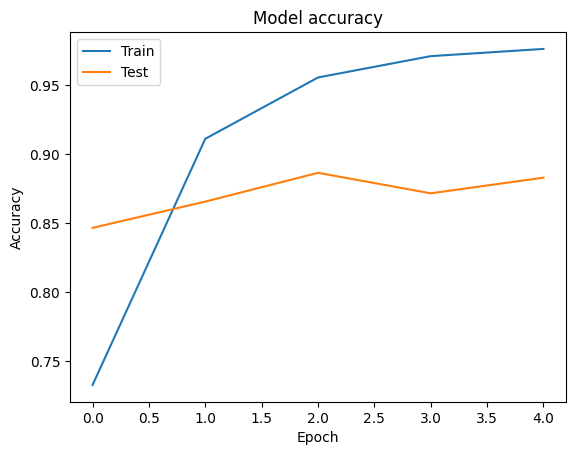

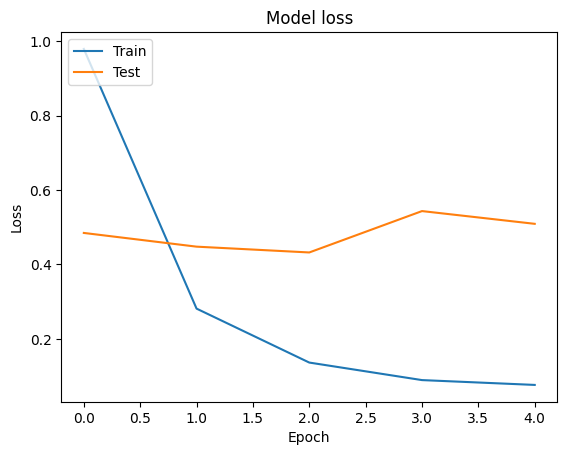

In [ ]:
# Plot training & validation accuracy values
'''plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()'''

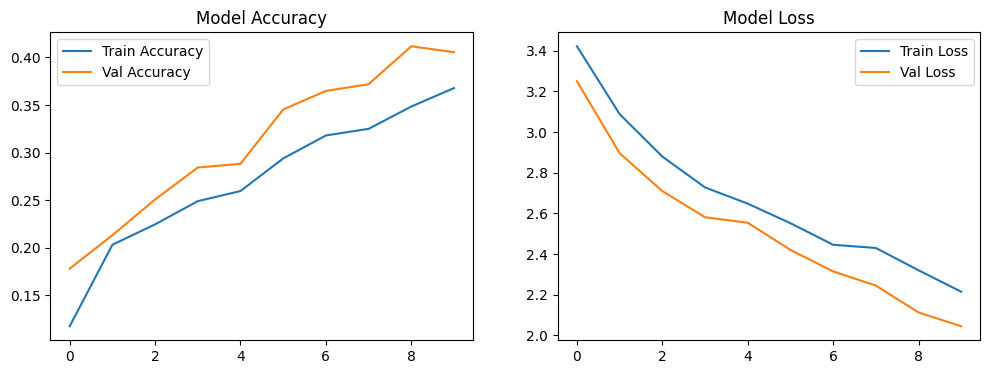

In [46]:
# model timing saved to train faster then checking loss and accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [47]:
# Get the final values from the last epoch of training
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"--- Final Training Results ---")
print(f"Accuracy: {final_train_acc * 100:.2f}%")
print(f"Loss: {final_train_loss:.4f}")

print(f"\n--- Final Validation Results ---")
print(f"Accuracy: {final_val_acc * 100:.2f}%")
print(f"Loss: {final_val_loss:.4f}")

--- Final Training Results ---
Accuracy: 36.78%
Loss: 2.2144

--- Final Validation Results ---
Accuracy: 40.55%
Loss: 2.0445


In [48]:
model.save("plant_disease_model2_v1.h5")
print("✅ Model saved as plant_disease_model_v1.h5")

✅ Model saved as plant_disease_model_v1.h5


**Building a Predictive System**

In [ ]:
# Function to Load and Preprocess the Image using Pillow

def load_and_preprocess_image(image_path, target_size=(224, 224)):
    
    img = Image.open(image_path)
    
    img = img.resize(target_size)
    
    img_array = np.array(img)
    
    img_array = np.expand_dims(img_array, axis=0)
    
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [50]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [51]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [52]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [56]:
import os

test_folder = os.path.join("..", "uneeded_plant", "testing dataset", "Potato___healthy")

if os.path.exists(test_folder):
    all_test_images = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.JPG', '.png'))]
    
    if len(all_test_images) > 0:
        image_path = os.path.join(test_folder, all_test_images[0])
        print(f"✅ Success! Testing with image: {image_path}")

        predicted_class_name = predict_image_class(model, image_path, class_indices)

        print("--- Result ---")
        print("Predicted Class Name:", predicted_class_name)
    else:
        print("❌ Folder found, but it is EMPTY. Add an image to it!")
else:
    print("❌ Still can't find the folder!")
    print(f"I was looking here: {os.path.abspath(test_folder)}")

✅ Success! Testing with image: ..\uneeded_plant\testing dataset\Potato___healthy\00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
--- Result ---
Predicted Class Name: Tomato___Tomato_Yellow_Leaf_Curl_Virus


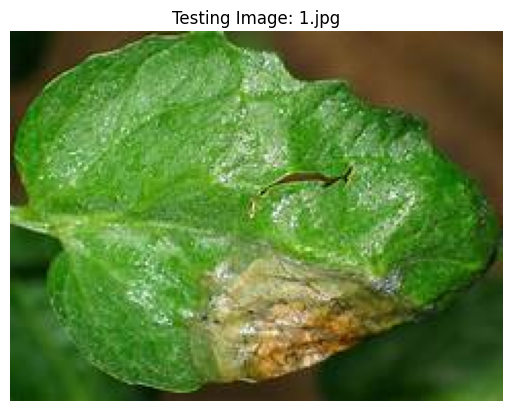

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
🎯 FINAL PREDICTION: Orange___Haunglongbing_(Citrus_greening)


In [59]:

test_base_path = os.path.join("..", "uneeded_plant", "testing dataset")

target_file = "1.jpg" 
image_path = os.path.join(test_base_path, target_file)

# 3. Verify, Show, and Predict
if os.path.exists(image_path):
    # Show the image
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.title(f"Testing Image: {target_file}")
    plt.axis('off')
    plt.show()
    
    result = predict_image_class(model, image_path, class_indices)
    
    print("=" * 40)
    print(f"🎯 FINAL PREDICTION: {result}")
    print("=" * 40)
else:
    print(f"❌ File not found! Check if it is '1.jpg' or '1.JPG'")
    print(f"I am looking here: {os.path.abspath(image_path)}")

In [60]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predictions for the whole validation set
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Print a report
print('--- Classification Report ---')
target_names = list(train_generator.class_indices.keys())
print(classification_report(validation_generator.classes, y_pred, target_names=target_names))

170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step
--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.00      0.00      0.00       126
                                 Apple___Black_rot       0.00      0.00      0.00       124
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                                   Apple___healthy       0.03      0.02      0.03       329
                               Blueberry___healthy       0.02      0.02      0.02       300
          Cherry_(including_sour)___Powdery_mildew       0.00      0.00      0.00       210
                 Cherry_(including_sour)___healthy       0.00      0.00      0.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00       102
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00       238
      

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jagdish singh\jupyter311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jagdish singh\jupyter311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Generating predictions for the validation set...
170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step


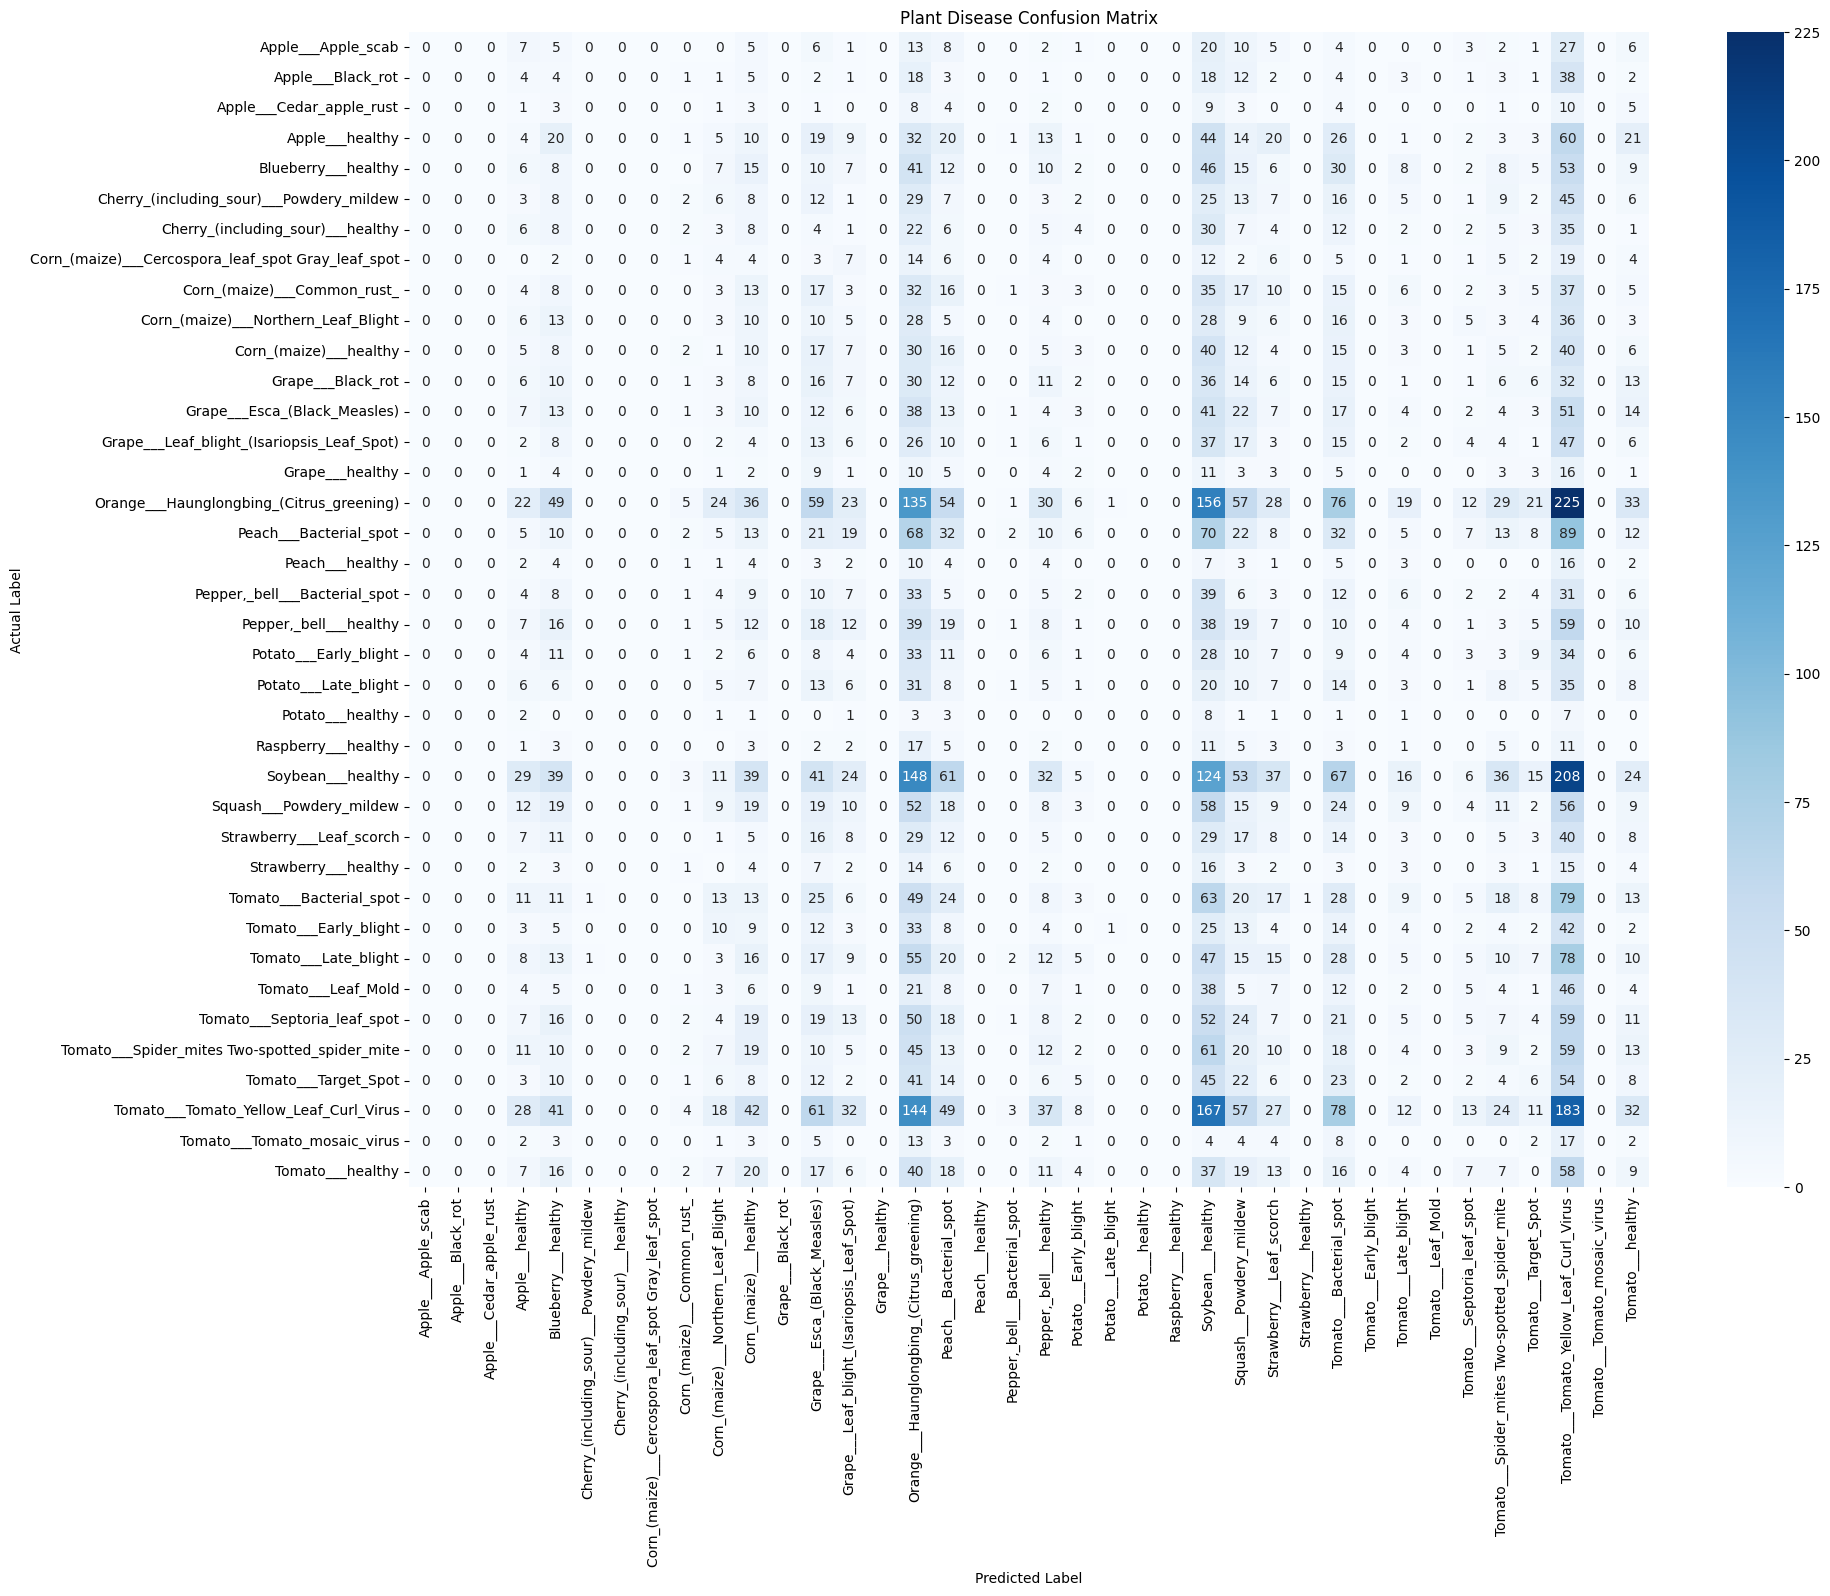

In [61]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Get the actual labels and the model's predictions
# Note: This might take a minute as it predicts the whole validation set
print("Generating predictions for the validation set...")
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting using Seaborn for better visibility in VS Code
plt.figure(figsize=(20, 15)) # Large size to fit 38 labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=validation_generator.class_indices.keys(), 
            yticklabels=validation_generator.class_indices.keys())

plt.title('Plant Disease Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# these predcitons are for model trained in few minutes only after saveing 7 hours of training 
# therfore accuracy will be very low 

total_images = len(y_true)

# 2. Count where the prediction MATCHES the actual label
correctly_classified = np.sum(y_true == y_pred)

# 3. Count where they DO NOT match
misclassified = total_images - correctly_classified

# 4. Calculate accuracy percentage manually for double-check
accuracy_percent = (correctly_classified / total_images) * 100

print("-" * 30)
print(f"📊 FINAL CLASSIFICATION REPORT")
print("-" * 30)
print(f"✅ Correctly Classified: {correctly_classified}")
print(f"❌ Misclassified:         {misclassified}")
print(f"📈 Total Images Tested:   {total_images}")
print(f"🏆 Final Accuracy:       {accuracy_percent:.2f}%")
print("-" * 30)

------------------------------
📊 FINAL CLASSIFICATION REPORT
------------------------------
✅ Correctly Classified: 611
❌ Misclassified:         10238
📈 Total Images Tested:   10849
🏆 Final Accuracy:       5.63%
------------------------------


**Save the model to Google drive or local**

In [ ]:
model.save('drive/MyDrive/Youtube/trained_models/plant_disease_prediction_model.h5')

In [ ]:
model.save('drive/MyDrive/Youtube/trained_models/plant_disease_prediction_model.h5')